# Complete Kaggle NLP EDA Notebook — No Pretrained / No Internet

Notebook ini untuk EDA task NLP/text.

Aturan seleksi:
- Tidak boleh pretrained model.
- Tidak boleh download external data/model/tokenizer.
- Jadi EDA harus mendukung baseline klasik dan RNN/CNN from-scratch.

Tujuan:
- Detect text columns, target, ID, task type.
- Analyze text length, language/noise, duplicates, leakage, class imbalance.
- Inspect vocabulary, n-grams, OOV risk, train/test drift.
- Prepare preprocessing recommendations untuk TF-IDF, CNN/RNN/Embedding from-scratch.

In [3]:
# ============================================================
# 0. Imports and Configuration
# ============================================================

import os
import re
import gc
import json
import math
import string
import warnings
from pathlib import Path
from pprint import pprint
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 300)

CONFIG = {
    "TRAIN_FILE": None,
    "TEST_FILE": None,
    "SAMPLE_SUBMISSION_FILE": None,

    "TARGET_COL": None,
    "ID_COL": None,
    "TEXT_COLS": None,

    # None, "binary", "multiclass", "regression"
    "TASK_TYPE": None,

    "MAX_ROWS_FOR_HEAVY_EDA": 50_000,
    "MAX_TEXT_EXAMPLES": 50,
    "TOP_NGRAMS": 50,
    "MIN_TOKEN_FREQ_FOR_VOCAB": 2,
}

print("kerja weh")

kerja weh


## 1. Input Discovery

Use case:
- NLP competitions biasanya tetap CSV-based.
- Text bisa di kolom `text`, `review`, `question`, `title`, `body`, `comment`, dll.

In [5]:
# ============================================================
# 1. Input Discovery
# ============================================================

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    INPUT_ROOT = Path(".")

csv_files = sorted([str(p) for p in INPUT_ROOT.glob("**/*.csv")])

print(f"Found {len(csv_files)} CSV files")
for i, f in enumerate(csv_files):
    try:
        preview = pd.read_csv(f, nrows=3)
        print(f"{i:02d}. {f}")
        print(f"    columns={list(preview.columns)}")
    except Exception as e:
        print(f"{i:02d}. {f} | cannot preview: {repr(e)}")

def pick_file(files, keywords):
    keywords = [k.lower() for k in keywords]
    matches = []
    for f in files:
        name = Path(f).name.lower()
        if any(k in name for k in keywords):
            matches.append(f)
    return matches[0] if matches else None

if CONFIG["TRAIN_FILE"] is None:
    CONFIG["TRAIN_FILE"] = pick_file(csv_files, ["train"])
if CONFIG["TEST_FILE"] is None:
    CONFIG["TEST_FILE"] = pick_file(csv_files, ["test"])
if CONFIG["SAMPLE_SUBMISSION_FILE"] is None:
    CONFIG["SAMPLE_SUBMISSION_FILE"] = pick_file(csv_files, ["sample", "submission"])

print("\nSelected files:")
pprint({k: CONFIG[k] for k in ["TRAIN_FILE", "TEST_FILE", "SAMPLE_SUBMISSION_FILE"]})

assert CONFIG["TRAIN_FILE"] is not None, "TRAIN_FILE belum ditemukan."
assert CONFIG["TEST_FILE"] is not None, "TEST_FILE belum ditemukan."

Found 3 CSV files
00. /kaggle/input/datasets/laurentiusfarel/ai-something/sample_submission.csv
    columns=['id', 'evaluation']
01. /kaggle/input/datasets/laurentiusfarel/ai-something/test.csv
    columns=['review_id', 'paper_id', 'preliminary_decision', 'confidence', 'orientation', 'lan', 'remarks', 'timespan', 'text']
02. /kaggle/input/datasets/laurentiusfarel/ai-something/train.csv
    columns=['review_id', 'paper_id', 'preliminary_decision', 'confidence', 'orientation', 'lan', 'remarks', 'timespan', 'text', 'evaluation']

Selected files:
{'SAMPLE_SUBMISSION_FILE': '/kaggle/input/datasets/laurentiusfarel/ai-something/sample_submission.csv',
 'TEST_FILE': '/kaggle/input/datasets/laurentiusfarel/ai-something/test.csv',
 'TRAIN_FILE': '/kaggle/input/datasets/laurentiusfarel/ai-something/train.csv'}


In [6]:
# ============================================================
# 2. Load Data
# ============================================================

train = pd.read_csv(CONFIG["TRAIN_FILE"])
test = pd.read_csv(CONFIG["TEST_FILE"])

sample_submission = None
if CONFIG["SAMPLE_SUBMISSION_FILE"] is not None:
    sample_submission = pd.read_csv(CONFIG["SAMPLE_SUBMISSION_FILE"])

print("train:", train.shape)
print("test :", test.shape)
if sample_submission is not None:
    print("sample_submission:", sample_submission.shape)

display(train.head())
display(test.head())
if sample_submission is not None:
    display(sample_submission.head())

train: (324, 10)
test : (81, 9)
sample_submission: (81, 2)


,review_id,paper_id,preliminary_decision,confidence,orientation,lan,remarks,timespan,text,evaluation
0,92_4,92,accept,2.0,1,es,NaN,2014-07-05,"Me parece un artículo interesante que pudo centrarse más en el desarrollo de una aplicación sobre Kurogo (un producto atractivo descrito en el artículo) que en el estudio de la ubicuidad de tecnologías para su interoperabilidad. En este punto me saltan diversas dudas, ya que el estudio concluye...",1
1,106_2,106,accept,3.0,1,es,"El paper es muy bueno, pero no es original, ya que tiene un alto índice de similitud con otros, no pudiendo identificar si se trata de los mismos autores. De ahí que la recomendación es débil. Definitivamente no postula a Ingeniere.",2014-07-05,"Muy buen artículo para comprender la ubicación espacial de objetos, con propósitos de control, en este caso aplicable a un conjunto de robot en un juego de futbol.",1
2,88_2,88,accept,3.0,0,es,"La idea es buena pero debe arreglar lo que se pide en el listado de correcciones tanto de formato como de contenido. Y sobre todo el título que es muy ""grande"" en relación a lo que se presenta que es una aplicación y no un nuevo modelo emergente.",2013-07-05,"Correcciones de Formato: 1.\tEn palabras claves dejar sólo 5 las más relevantes. 2.\tEliminar las siguientes expresiones: •\t“De ahí que en el sistema solar desentone la chatarra de los satélites artificiales, o en el sistema circulatorio sanguíneo produzca hemorragia la incrustación de una cu...",1
3,160_2,160,accept,4.0,1,es,NaN,2015-07-05,"El artículo es interesante, abarca en profundidad muchos términos. Algunas observaciones son: - Deben ser entre 5 y 10 palabras clave. - Cambiar palabra ""entonro"" - Quitar acento a ""éste modo"" - No usar color según instrucciones de papers Infonor - Cambiar palabra ""Dendrograma"" - Revisar ""reali...",2
4,139_1,139,accept,4.0,0,es,NaN,2015-07-05,"Los autores proponen el análisis de los datos a través de la metodología CRISP-DM, pero en el desarrollo no se utiliza el mismo. Los autores hacen uso de la herramienta WEKA y de los algoritmo que tiene implementados dicha herramienta. Tal vez fuera mejor pensar en un algoritmo propio para este...",1


,review_id,paper_id,preliminary_decision,confidence,orientation,lan,remarks,timespan,text
0,112_1,112,reject,4,0,es,NaN,2014-07-05,"Me parece un trabajo interesante, con énfasis en cubrir brechas prácticas. Su contenido y estructura están técnicamente bien presentados. Sin embargo, por otro lado, no existe una distinción clara entre los trabajos previos y la propuesta original de este trabajo. El artículo expone que existen ..."
1,104_1,104,accept,4,0,es,"Al trabajo le falta ""algo de"" practica. Ahora solo es revisión de la literatura. Cuando pruebe el modelo será bastante interesante.",2014-07-05,"Correcciones a artículo: “Manejo de información, un continuo reto de la tecnología”. Evaluación general El trabajo es interesante pero falta algo de implementación, pues en general es una buena revisión a la literatura existente. Al leer el artículo da la impresión que falta algo (la implementa..."
2,108_2,108,reject,4,-1,es,NaN,2014-07-05,"El artículo presenta un análisis teórico sobre sistemas SCADA. No hay evidencia sobre la aplicación en un caso de estudio. El Resumen no es adecuado, tampoco la introducción. La sección de Resultados y la sección de Conclusiones no presentan aportes para un artículo científico o que muestre ..."
3,74_1,74,accept,4,0,es,NaN,2013-07-05,Los comentarios aparecen en el archivo adjunto
4,119_1,119,accept,4,0,es,NaN,2014-07-05,"El artículo describe una interesante aplicación de control de un dispositivo físico (para el caso en estudio, un robot móvil de Lego Mindstorms), mediante el procesamiento de las señales derivadas de cambios de índole facial y/o mental, provenientes de un casco Emotiv EEG, el cual realiza un el..."


,id,evaluation
0,112_1,0
1,104_1,0
2,108_2,0
3,74_1,0
4,119_1,0


## 2. Target, ID, Text Column Detection

Use case:
- Multi-column text umum terjadi: `title + body`, `question1 + question2`, `premise + hypothesis`.
- Jangan asal gabung jika task pairwise; tapi untuk baseline cepat, gabung dengan separator sering cukup.

In [7]:
# ============================================================
# 2b. Auto Detect Target, ID, Text Columns
# ============================================================

def auto_detect_target(train_df, test_df):
    diff = [c for c in train_df.columns if c not in test_df.columns]
    if len(diff) == 1:
        return diff[0]
    for c in ["target", "label", "class", "sentiment", "score", "y", "category"]:
        if c in train_df.columns and c not in test_df.columns:
            return c
    return train_df.columns[-1]

def auto_detect_id(train_df, test_df, sample_df=None):
    common = [c for c in train_df.columns if c in test_df.columns]
    if sample_df is not None and len(sample_df.columns) > 0:
        first = sample_df.columns[0]
        if first in test_df.columns:
            return first
    for c in ["id", "ID", "Id", "row_id", "text_id", "review_id", "qid"]:
        if c in common:
            return c
    for c in common:
        if train_df[c].is_unique and test_df[c].is_unique:
            return c
    return None

def text_column_score(s, colname):
    if s.dtype != "object":
        return -1
    ss = s.dropna().astype(str)
    if len(ss) == 0:
        return -1
    avg_len = ss.str.len().mean()
    median_len = ss.str.len().median()
    unique_ratio = ss.nunique() / max(len(ss), 1)
    name_bonus = 0
    if any(k in colname.lower() for k in ["text", "review", "comment", "sentence", "question", "title", "body", "description", "content", "tweet"]):
        name_bonus = 10
    return avg_len * 0.05 + median_len * 0.05 + unique_ratio * 10 + name_bonus

def auto_detect_text_cols(train_df, test_df, target_col, id_col):
    common = [c for c in train_df.columns if c in test_df.columns and c not in [target_col, id_col]]
    scores = []
    for c in common:
        combined = pd.concat([train_df[c], test_df[c]], axis=0)
        score = text_column_score(combined, c)
        if score > 0:
            ss = combined.dropna().astype(str)
            avg_len = ss.str.len().mean() if len(ss) else 0
            unique_ratio = ss.nunique() / max(len(ss), 1) if len(ss) else 0
            # Keep likely text fields.
            if avg_len >= 10 or unique_ratio > 0.2 or any(k in c.lower() for k in ["text", "review", "comment", "sentence", "question", "title", "body", "description", "content", "tweet"]):
                scores.append((c, score, avg_len, unique_ratio))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores]

if CONFIG["TARGET_COL"] is None:
    CONFIG["TARGET_COL"] = auto_detect_target(train, test)
if CONFIG["ID_COL"] is None:
    CONFIG["ID_COL"] = auto_detect_id(train, test, sample_submission)
if CONFIG["TEXT_COLS"] is None:
    CONFIG["TEXT_COLS"] = auto_detect_text_cols(train, test, CONFIG["TARGET_COL"], CONFIG["ID_COL"])

target_col = CONFIG["TARGET_COL"]
id_col = CONFIG["ID_COL"]
text_cols = CONFIG["TEXT_COLS"]

print("target_col:", target_col)
print("id_col    :", id_col)
print("text_cols :", text_cols)

assert target_col in train.columns, "Target tidak ada di train."
assert len(text_cols) > 0, "Text columns tidak ketemu. Set manual CONFIG['TEXT_COLS']."

target_col: evaluation
id_col    : review_id
text_cols : ['text', 'remarks', 'timespan']


In [8]:
# ============================================================
# 2c. Infer Task Type
# ============================================================

y_raw = train[target_col]

def infer_task_type(y):
    if CONFIG["TASK_TYPE"] is not None:
        return CONFIG["TASK_TYPE"]
    if y.dtype == "object" or str(y.dtype).startswith("category") or str(y.dtype) == "bool":
        return "binary" if y.nunique(dropna=True) <= 2 else "multiclass"
    nunique = y.nunique(dropna=True)
    if nunique <= 20 and nunique / max(len(y), 1) < 0.05:
        return "binary" if nunique <= 2 else "multiclass"
    return "regression"

task_type = infer_task_type(y_raw)
print("task_type:", task_type)
display(y_raw.value_counts(dropna=False).head(50).to_frame("count"))

task_type: multiclass


,count
evaluation,
2,87
1,70
-2,69
0,51
-1,47


## 3. Build Combined Text and Basic Cleaning

Use case:
- For EDA, build a combined text column so all text stats are easy.
- Keep original text too; over-cleaning can remove signal.
- Separator token helps distinguish multiple text fields.

In [9]:
# ============================================================
# 3. Text Construction and Light Cleaning
# ============================================================

def normalize_space(x):
    x = "" if pd.isna(x) else str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def build_text(df, cols):
    parts = []
    for c in cols:
        parts.append(df[c].map(normalize_space).fillna(""))
    text = parts[0]
    for i, p in enumerate(parts[1:], 1):
        text = text + f" [SEP{i}] " + p
    return text

train_text = build_text(train, text_cols)
test_text = build_text(test, text_cols)

train["_eda_text"] = train_text
test["_eda_text"] = test_text

print("Text examples:")
for i in range(min(5, len(train))):
    print("=" * 100)
    print("TARGET:", train.iloc[i][target_col])
    print(train_text.iloc[i][:1000])

Text examples:
TARGET: 1
Me parece un artículo interesante que pudo centrarse más en el desarrollo de una aplicación sobre Kurogo (un producto atractivo descrito en el artículo) que en el estudio de la ubicuidad de tecnologías para su interoperabilidad. En este punto me saltan diversas dudas, ya que el estudio concluye la siguiente configuración de interoperabilidad: "DVB-2T como el estándar internacional de transmisión de TVDi escogido por Colombia, MHP como el middleware para la TVDi, MPEG como el formato de codificación y decodificación de audio y video de los contenidos y SCORM como estándar óptimo para la generación de contenidos." Eso significa que en los estudios se debió utilizar transmisión por tv digital??? Y, por lo que entiendo, se usó un "logitech revenue" lo que convierte al tv en una salida de una conexión a internet, por lo que sería lo mismo que las comparaciones sobre un PC común. ¿Estoy en lo correcto? Con esta duda, aún me parece que el artículo puede ser interesant

## 4. Text Length and Structure Features

Use case:
- Length can be a very strong signal.
- For RNN/CNN from-scratch, length distribution determines `max_len`.
- For TF-IDF, extremely long texts may need `max_features`, pruning, or chunking.

Train text stats


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
char_len,324.0,1057.891975,822.299553,26.000000,26.000000,168.850000,525.250000,857.000000,1297.250000,2685.000000,4278.710000,4852.000000
word_count,324.0,168.777778,132.938590,3.000000,3.000000,26.300000,81.000000,135.500000,210.250000,418.650000,689.570000,771.000000
unique_word_count,324.0,107.172840,66.686883,3.000000,3.000000,24.600000,63.000000,96.000000,135.250000,236.250000,334.860000,420.000000
avg_word_len,324.0,5.364562,0.442095,4.618785,4.704258,4.845975,5.103154,5.293365,5.522118,5.975763,7.333333,7.333333
punct_count,324.0,32.481481,30.589507,6.000000,6.000000,8.150000,15.000000,23.000000,39.000000,80.850000,167.770000,262.000000
digit_count,324.0,14.348765,12.613275,10.000000,10.000000,10.000000,10.000000,10.000000,14.000000,29.000000,45.540000,195.000000
upper_count,324.0,27.287037,27.377778,6.000000,6.000000,8.000000,12.000000,18.000000,34.000000,66.850000,143.160000,217.000000
url_count,324.0,0.061728,0.346434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000
email_count,324.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hashtag_count,324.0,0.021605,0.337762,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000


Test text stats


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
char_len,81.0,1102.370370,930.913925,72.000000,100.00000,272.000000,541.000000,832.000000,1476.000000,2433.000000,3948.600000,6555.000000
word_count,81.0,175.654321,150.795570,10.000000,13.20000,44.000000,86.000000,135.000000,235.000000,410.000000,631.400000,1045.000000
unique_word_count,81.0,107.802469,63.427403,10.000000,13.20000,38.000000,66.000000,89.000000,146.000000,229.000000,260.200000,365.000000
avg_word_len,81.0,5.356751,0.380783,4.716981,4.74717,4.873786,5.119565,5.273684,5.585635,5.978723,6.501905,6.642857
punct_count,81.0,31.333333,26.111779,6.000000,6.80000,8.000000,14.000000,24.000000,40.000000,74.000000,131.600000,146.000000
digit_count,81.0,12.790123,5.467440,10.000000,10.00000,10.000000,10.000000,11.000000,13.000000,19.000000,34.600000,49.000000
upper_count,81.0,23.777778,16.983080,7.000000,7.00000,8.000000,12.000000,19.000000,27.000000,61.000000,82.400000,92.000000
url_count,81.0,0.012346,0.111111,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000
email_count,81.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hashtag_count,81.0,0.037037,0.333333,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,3.000000


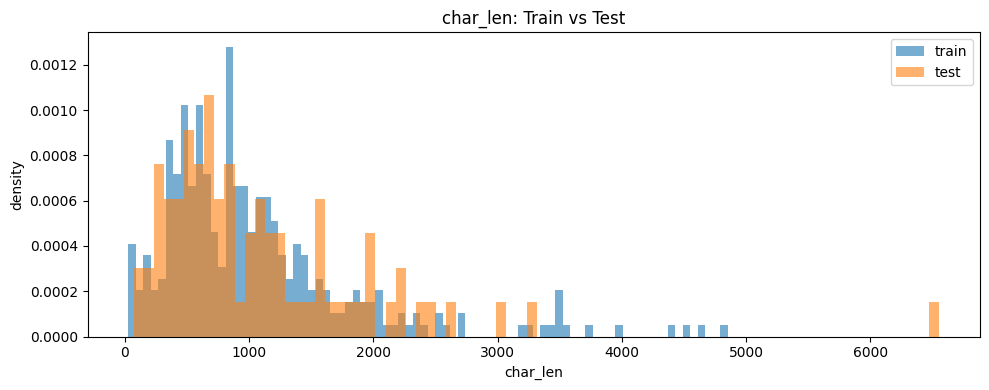

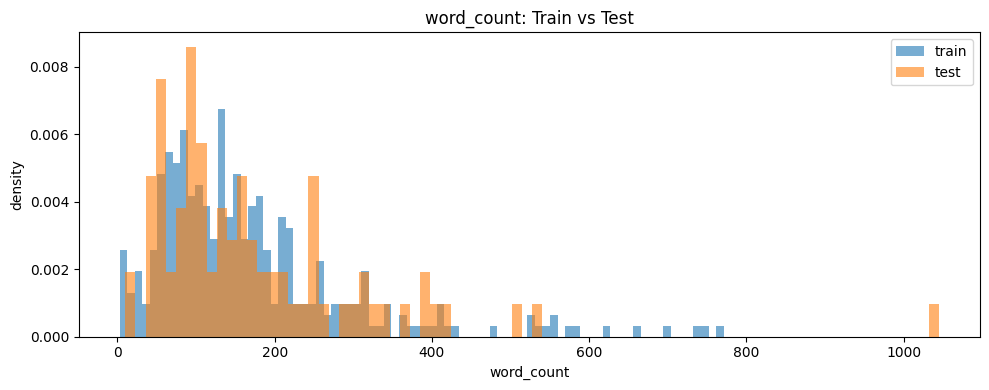

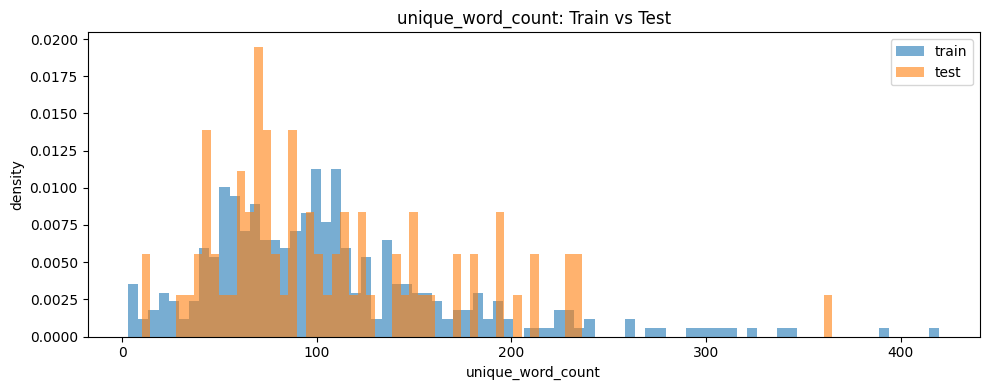

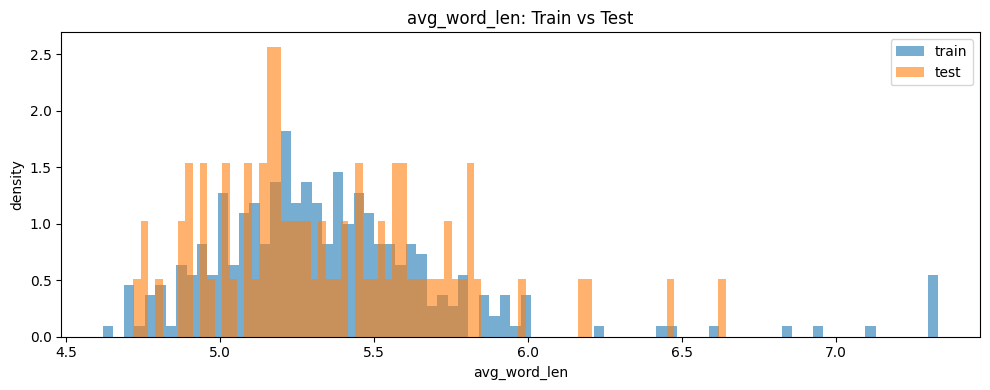

In [10]:
# ============================================================
# 4. Text Length Features
# ============================================================

def count_words(x):
    return len(str(x).split())

def count_unique_words(x):
    toks = str(x).split()
    return len(set(toks))

def text_stats(series):
    s = series.fillna("").astype(str)
    return pd.DataFrame({
        "char_len": s.str.len(),
        "word_count": s.map(count_words),
        "unique_word_count": s.map(count_unique_words),
        "avg_word_len": s.map(lambda x: np.mean([len(t) for t in x.split()]) if len(x.split()) else 0),
        "punct_count": s.map(lambda x: sum(ch in string.punctuation for ch in x)),
        "digit_count": s.map(lambda x: sum(ch.isdigit() for ch in x)),
        "upper_count": s.map(lambda x: sum(ch.isupper() for ch in x)),
        "url_count": s.map(lambda x: len(re.findall(r"https?://\S+|www\.\S+", x))),
        "email_count": s.map(lambda x: len(re.findall(r"[\w\.-]+@[\w\.-]+", x))),
        "hashtag_count": s.map(lambda x: len(re.findall(r"#\w+", x))),
        "mention_count": s.map(lambda x: len(re.findall(r"@\w+", x))),
    })

train_stats = text_stats(train_text)
test_stats = text_stats(test_text)

print("Train text stats")
display(train_stats.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("Test text stats")
display(test_stats.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

for col in ["char_len", "word_count", "unique_word_count", "avg_word_len"]:
    plt.figure(figsize=(10, 4))
    plt.hist(train_stats[col], bins=80, alpha=0.6, density=True, label="train")
    plt.hist(test_stats[col], bins=80, alpha=0.6, density=True, label="test")
    plt.title(f"{col}: Train vs Test")
    plt.xlabel(col)
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

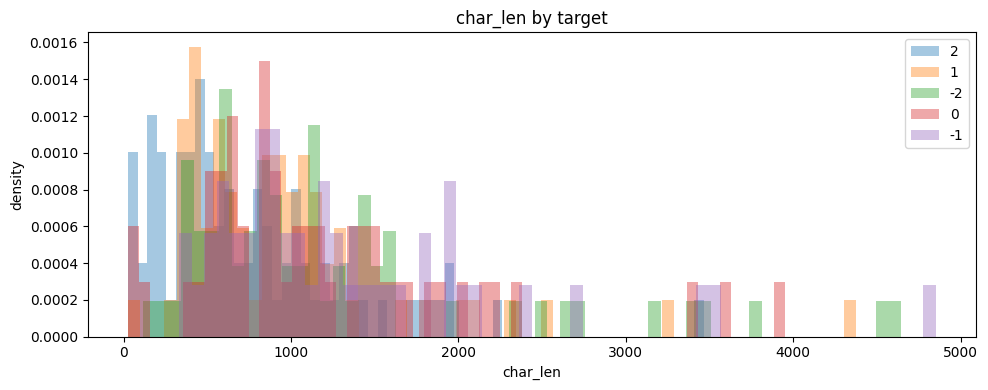

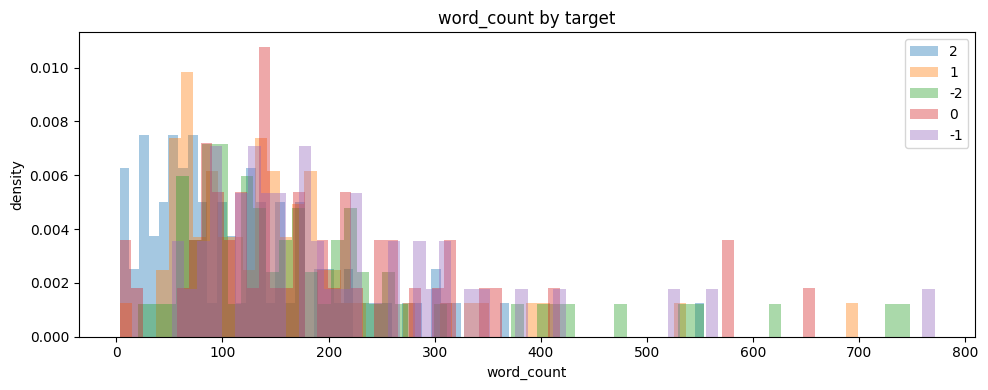

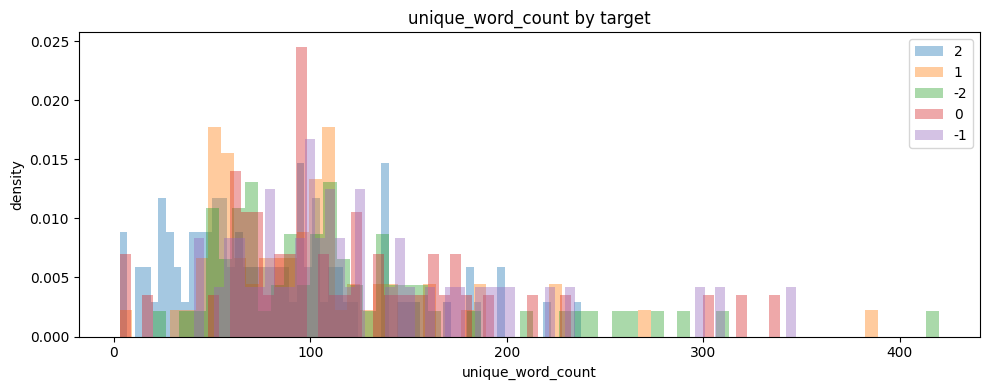

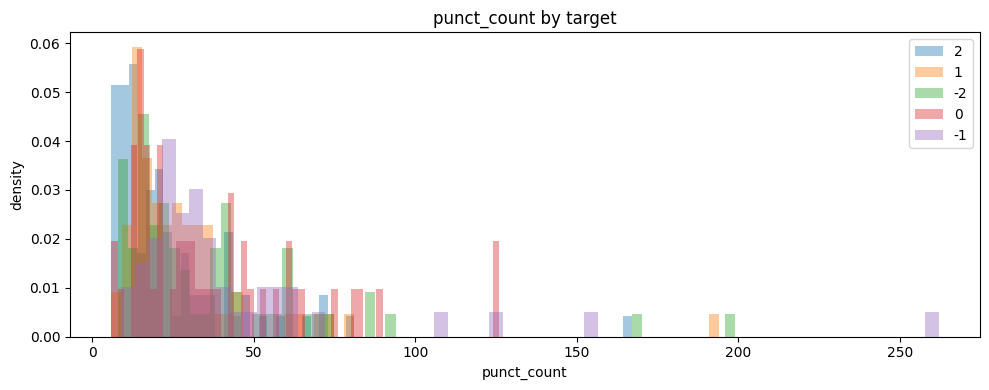

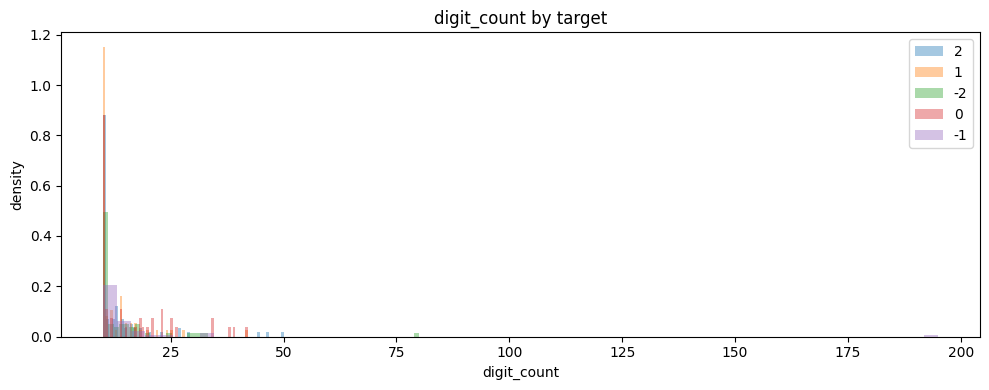

char_len                            word_count                          unique_word_count                         punct_count                         digit_count                    \
                   mean  median         std count        mean median         std count              mean median        std count        mean median        std count        mean median        std   
evaluation                                                                                                                                                                                           
-2          1246.449275   900.0  986.239196    69  197.913043  147.0  158.590551    69        121.652174  105.0  74.977217    69   36.362319   24.0  33.012908    69   14.115942   10.0   9.671876   
-1          1337.510638  1058.0  903.007027    47  212.574468  180.0  142.387980    47        128.978723  110.0  68.463094    47   43.617021   31.0  43.111359    47   17.212766   11.0  27.038568   
 0          1196.352941   953.0  829.591775    51  192.882353  150.0  138.632413    51        120.352941   98.0  70.300448    51   36.627451   28.0  28.083419    51   16.078431   11.0   8.733483   
 1           954.542857   836.5  702.558156    70  152.957143  136.5  114.339367    70        100.185714   94.5  59.660949    70   28.342857   22.0  25.307893    70   12.614286   10.0   5.305979   
 2           759.275862   586.0  597.224174    87  120.609195  100.0   96.727423    87         81.804598   73.0  52.910596    87   24.287356   18.0  22.675624    87   13.367816   10.0   7.474165   

                  
           count  
evaluation        
-2            69  
-1            47  
 0            51  
 1            70  
 2            87

In [11]:
# ============================================================
# 4b. Text Length vs Target
# ============================================================

if task_type in ["binary", "multiclass"]:
    tmp = pd.concat([train_stats, train[[target_col]].reset_index(drop=True)], axis=1)
    top_classes = train[target_col].value_counts().head(6).index.tolist()

    for stat_col in ["char_len", "word_count", "unique_word_count", "punct_count", "digit_count"]:
        plt.figure(figsize=(10, 4))
        for cls in top_classes:
            vals = tmp.loc[tmp[target_col] == cls, stat_col]
            plt.hist(vals, bins=60, alpha=0.4, density=True, label=str(cls))
        plt.title(f"{stat_col} by target")
        plt.xlabel(stat_col)
        plt.ylabel("density")
        plt.legend()
        plt.tight_layout()
        plt.show()

    length_summary = tmp.groupby(target_col)[["char_len", "word_count", "unique_word_count", "punct_count", "digit_count"]].agg(["mean", "median", "std", "count"])
    display(length_summary)
else:
    y_num = pd.to_numeric(train[target_col], errors="coerce").reset_index(drop=True)
    for stat_col in ["char_len", "word_count", "unique_word_count", "punct_count", "digit_count"]:
        plt.figure(figsize=(6, 4))
        plt.scatter(train_stats[stat_col], y_num, s=5, alpha=0.4)
        plt.title(f"{stat_col} vs target")
        plt.xlabel(stat_col)
        plt.ylabel(target_col)
        plt.tight_layout()
        plt.show()

## 5. Missing, Empty, Duplicate, and Leakage Checks

Use case:
- Empty text may need special token.
- Duplicate text with conflicting labels is dangerous.
- Same text appearing in train and test may indicate leakage or repeated examples.

In [12]:
# ============================================================
# 5. Missing, Empty, Duplicate, Leakage
# ============================================================

for c in text_cols:
    print(f"Column: {c}")
    print("  train missing:", train[c].isna().sum(), "pct", train[c].isna().mean())
    print("  test missing :", test[c].isna().sum(), "pct", test[c].isna().mean())
    print("  train empty after strip:", train[c].map(normalize_space).eq("").sum())
    print("  test empty after strip :", test[c].map(normalize_space).eq("").sum())

print("\nCombined text empty:")
print("train:", train_text.eq("").sum())
print("test :", test_text.eq("").sum())

print("\nDuplicate combined texts:")
print("train duplicate text rows:", train_text.duplicated().sum())
print("test duplicate text rows :", test_text.duplicated().sum())

# Duplicates with multiple labels
dup = train.groupby("_eda_text")[target_col].nunique(dropna=False)
conflicting = dup[dup > 1]
print("Duplicate texts with conflicting labels:", len(conflicting))
if len(conflicting) > 0:
    conflict_texts = conflicting.head(20).index
    display(train[train["_eda_text"].isin(conflict_texts)][["_eda_text", target_col]].sort_values("_eda_text").head(100))

# Train-test text overlap
train_text_set = set(train_text)
test_text_set = set(test_text)
overlap = train_text_set & test_text_set
print("Exact train/test text overlap:", len(overlap))
if len(overlap) > 0:
    overlap_sample = list(overlap)[:20]
    display(pd.DataFrame({"overlap_text_sample": overlap_sample}))

Column: text
  train missing: 6 pct 0.018518518518518517
  test missing : 0 pct 0.0
  train empty after strip: 6
  test empty after strip : 0
Column: remarks
  train missing: 233 pct 0.7191358024691358
  test missing : 61 pct 0.7530864197530864
  train empty after strip: 233
  test empty after strip : 61
Column: timespan
  train missing: 0 pct 0.0
  test missing : 0 pct 0.0
  train empty after strip: 0
  test empty after strip : 0

Combined text empty:
train: 0
test : 0

Duplicate combined texts:
train duplicate text rows: 5
test duplicate text rows : 0
Duplicate texts with conflicting labels: 1


,_eda_text,evaluation
11,[SEP1] [SEP2] 2010-07-05,0
150,[SEP1] [SEP2] 2010-07-05,2
158,[SEP1] [SEP2] 2010-07-05,2
190,[SEP1] [SEP2] 2010-07-05,2
316,[SEP1] [SEP2] 2010-07-05,1
321,[SEP1] [SEP2] 2010-07-05,0


Exact train/test text overlap: 0


## 6. Tokenization and Vocabulary Analysis

Use case:
- For CNN/RNN from-scratch, vocabulary size and token frequency determine embedding table.
- Rare words can be mapped to `<UNK>`.
- Train/test OOV estimates help choose char-level features or subword-like char CNN.

Train vocab size: 6123
Test vocab size : 2656
Tokens only in train: 4191
Tokens only in test : 724
Test OOV token types vs train: 0.27259036144578314
Test OOV token frequency rate: 0.06122734588202365


,token,count
0,de,3584
1,la,1921
2,el,1719
3,en,1661
4,que,1197
5,se,1085
6,y,1073
7,no,861
8,es,780
9,a,753


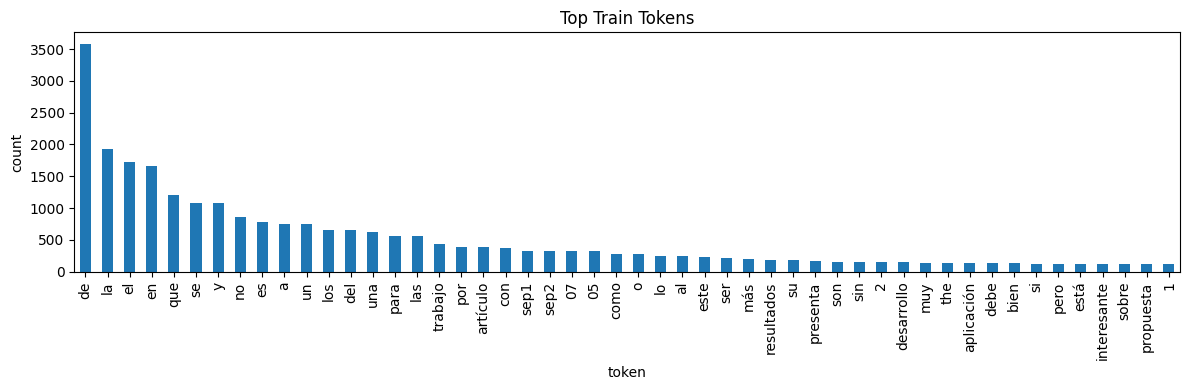

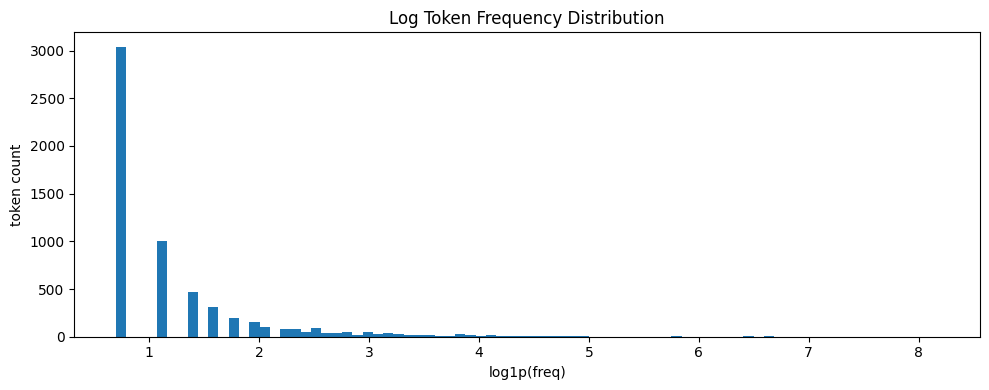

Vocab size with min_freq >= 1: 6123
Vocab size with min_freq >= 2: 3084
Vocab size with min_freq >= 3: 2082
Vocab size with min_freq >= 5: 1298
Vocab size with min_freq >= 10: 683
Vocab size with min_freq >= 20: 344
Vocab size with min_freq >= 50: 139


In [13]:
# ============================================================
# 6. Tokenization and Vocabulary
# ============================================================

TOKEN_PATTERN = re.compile(r"\b\w+\b", flags=re.UNICODE)

def simple_tokenize(text, lower=True):
    text = str(text)
    if lower:
        text = text.lower()
    return TOKEN_PATTERN.findall(text)

def build_counter(series, max_rows=None):
    counter = Counter()
    iterable = series
    if max_rows is not None and len(series) > max_rows:
        iterable = series.sample(max_rows, random_state=RANDOM_STATE)
    for x in iterable:
        counter.update(simple_tokenize(x))
    return counter

train_counter = build_counter(train_text, max_rows=CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])
test_counter = build_counter(test_text, max_rows=CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])

print("Train vocab size:", len(train_counter))
print("Test vocab size :", len(test_counter))

train_vocab = set(train_counter)
test_vocab = set(test_counter)

print("Tokens only in train:", len(train_vocab - test_vocab))
print("Tokens only in test :", len(test_vocab - train_vocab))
print("Test OOV token types vs train:", len(test_vocab - train_vocab) / max(len(test_vocab), 1))

# Token-level OOV rate weighted by frequency
test_total_tokens = sum(test_counter.values())
test_oov_tokens = sum(cnt for tok, cnt in test_counter.items() if tok not in train_vocab)
print("Test OOV token frequency rate:", test_oov_tokens / max(test_total_tokens, 1))

top_train_tokens = pd.DataFrame(train_counter.most_common(100), columns=["token", "count"])
display(top_train_tokens)

plt.figure(figsize=(12, 4))
top_train_tokens.head(50).set_index("token")["count"].plot(kind="bar")
plt.title("Top Train Tokens")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

freqs = np.array(list(train_counter.values()))
plt.figure(figsize=(10, 4))
plt.hist(np.log1p(freqs), bins=80)
plt.title("Log Token Frequency Distribution")
plt.xlabel("log1p(freq)")
plt.ylabel("token count")
plt.tight_layout()
plt.show()

for min_freq in [1, 2, 3, 5, 10, 20, 50]:
    vocab_size = sum(1 for _, cnt in train_counter.items() if cnt >= min_freq)
    print(f"Vocab size with min_freq >= {min_freq}: {vocab_size}")

## 7. Character and Noise Analysis

Use case:
- Indonesian/multilingual/noisy datasets may contain emoji, hashtags, mentions, URLs.
- Character-level CNN can be useful when OOV is high.
- Decide whether to normalize URLs, mentions, numbers.

Train unique chars: 116
Test unique chars : 102


,char,count
0,,54599
1,e,36293
2,a,29022
3,o,21706
4,s,19337
5,n,18810
6,r,18303
7,i,17273
8,t,14496
9,l,14126


,train_pct,test_pct,abs_diff
has_repeated_punct,0.157407,0.123457,0.033951
has_non_ascii,0.935185,0.962963,0.027778
has_url,0.037037,0.012346,0.024691
has_hashtag,0.006173,0.012346,0.006173
has_mention,0.003086,0.000000,0.003086
has_email,0.000000,0.000000,0.000000
has_html,0.000000,0.000000,0.000000
has_digit,1.000000,1.000000,0.000000


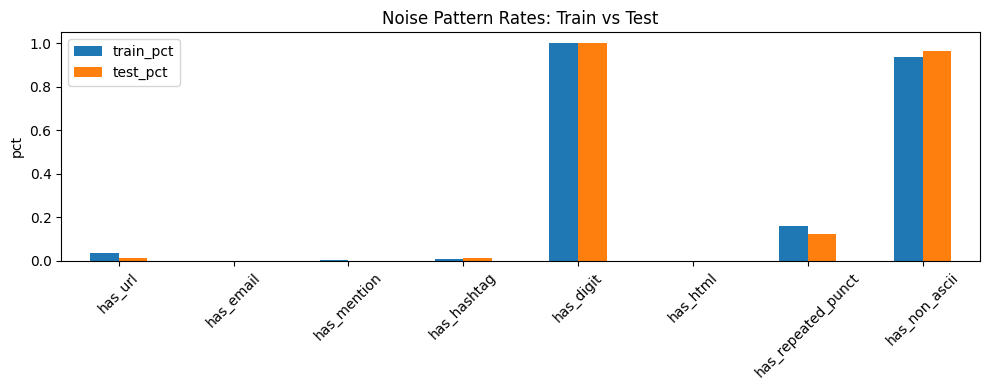

In [14]:
# ============================================================
# 7. Character and Noise Analysis
# ============================================================

def char_counter(series, max_rows=None):
    cnt = Counter()
    iterable = series
    if max_rows is not None and len(series) > max_rows:
        iterable = series.sample(max_rows, random_state=RANDOM_STATE)
    for x in iterable:
        cnt.update(str(x))
    return cnt

train_char_counter = char_counter(train_text, max_rows=CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])
test_char_counter = char_counter(test_text, max_rows=CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])

print("Train unique chars:", len(train_char_counter))
print("Test unique chars :", len(test_char_counter))

char_df = pd.DataFrame(train_char_counter.most_common(200), columns=["char", "count"])
display(char_df)

def noise_flags(series):
    s = series.fillna("").astype(str)
    return pd.DataFrame({
        "has_url": s.str.contains(r"https?://|www\.", regex=True),
        "has_email": s.str.contains(r"[\w\.-]+@[\w\.-]+", regex=True),
        "has_mention": s.str.contains(r"@\w+", regex=True),
        "has_hashtag": s.str.contains(r"#\w+", regex=True),
        "has_digit": s.str.contains(r"\d", regex=True),
        "has_html": s.str.contains(r"<[^>]+>", regex=True),
        "has_repeated_punct": s.str.contains(r"([!?.,])\1{2,}", regex=True),
        "has_non_ascii": s.map(lambda x: any(ord(ch) > 127 for ch in x)),
    })

train_noise = noise_flags(train_text)
test_noise = noise_flags(test_text)

noise_report = pd.DataFrame({
    "train_pct": train_noise.mean(),
    "test_pct": test_noise.mean(),
})
noise_report["abs_diff"] = (noise_report["train_pct"] - noise_report["test_pct"]).abs()
display(noise_report.sort_values("abs_diff", ascending=False))

noise_report[["train_pct", "test_pct"]].plot(kind="bar", figsize=(10, 4))
plt.title("Noise Pattern Rates: Train vs Test")
plt.ylabel("pct")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. N-gram Analysis

Use case:
- Top n-grams help understand domain and label signal.
- Class-specific n-grams are strong for TF-IDF/logistic baseline.
- For RNN/CNN, n-gram analysis helps decide whether word order matters.

Top ngrams (1, 1)


,ngram,count
0,de,3584
1,la,1921
2,el,1719
3,en,1661
4,que,1197
5,se,1085
6,y,1073
7,no,861
8,es,780
9,a,753


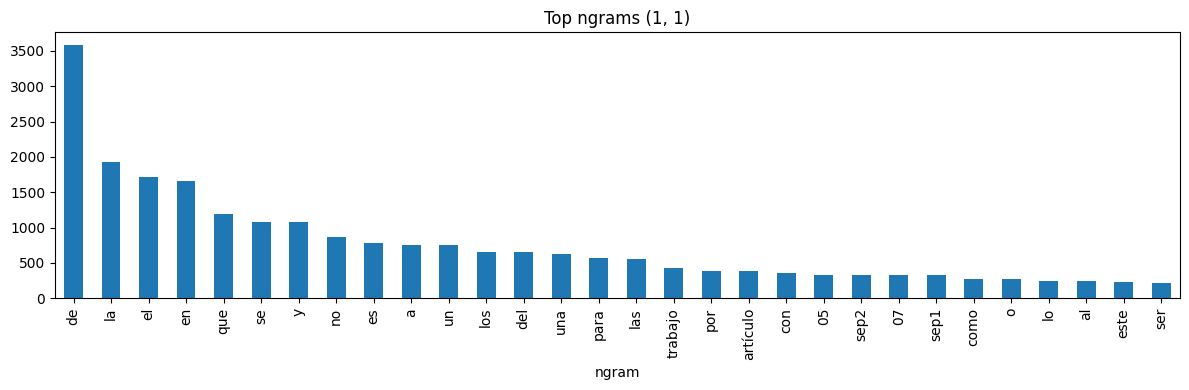

Top ngrams (2, 2)


,ngram,count
0,de la,411
1,en el,326
2,07 05,324
3,en la,295
4,sep1 sep2,233
5,el artículo,212
6,no se,192
7,que se,188
8,el trabajo,173
9,de las,153


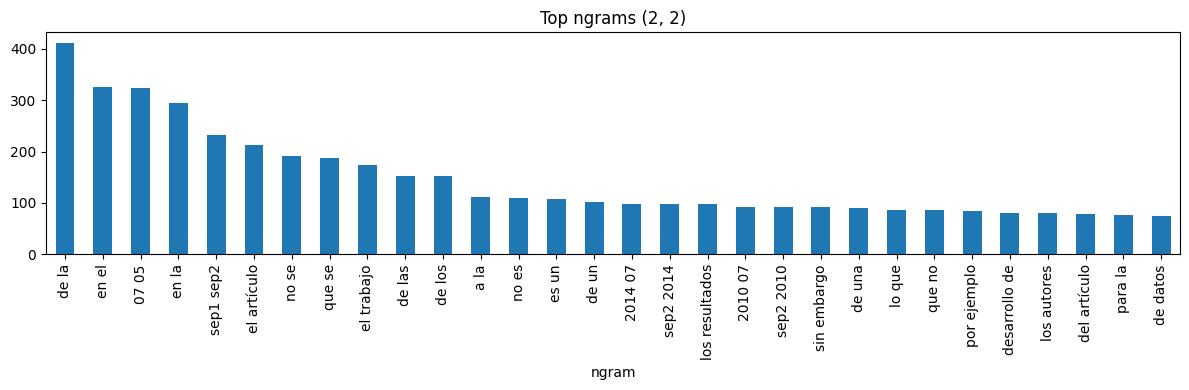

Top ngrams (3, 3)


,ngram,count
0,2014 07 05,99
1,sep2 2014 07,99
2,sep2 2010 07,93
3,2010 07 05,93
4,sep1 sep2 2010,75
5,sep1 sep2 2014,74
6,sep2 2015 07,66
7,sep2 2013 07,66
8,2013 07 05,66
9,2015 07 05,66


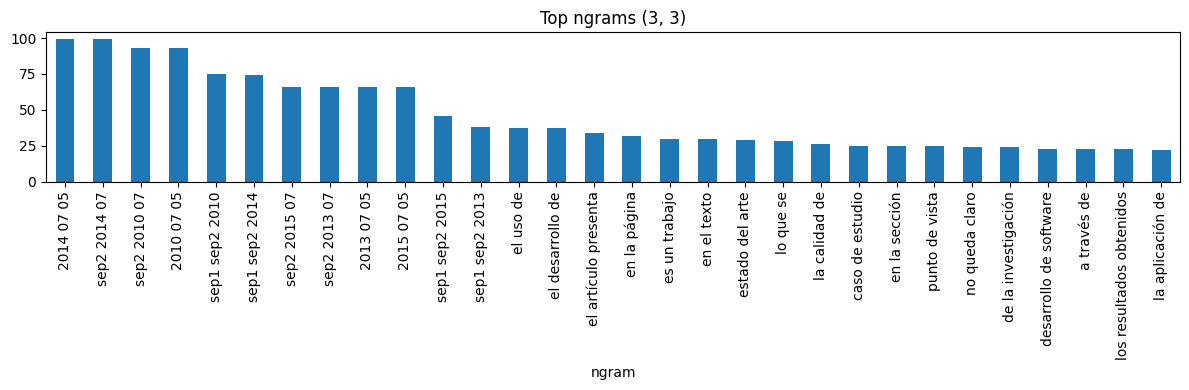

In [15]:
# ============================================================
# 8. Global N-gram Analysis
# ============================================================

def get_top_ngrams(texts, ngram_range=(1, 1), top_n=50, min_df=2, stop_words=None):
    vec = CountVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words=stop_words,
        max_features=100_000,
    )
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    order = np.argsort(counts)[::-1][:top_n]
    return pd.DataFrame({"ngram": terms[order], "count": counts[order]})

sample_text_for_ngrams = train_text
if len(sample_text_for_ngrams) > CONFIG["MAX_ROWS_FOR_HEAVY_EDA"]:
    sample_text_for_ngrams = sample_text_for_ngrams.sample(CONFIG["MAX_ROWS_FOR_HEAVY_EDA"], random_state=RANDOM_STATE)

for ngr in [(1,1), (2,2), (3,3)]:
    print(f"Top ngrams {ngr}")
    try:
        top_ng = get_top_ngrams(sample_text_for_ngrams, ngram_range=ngr, top_n=CONFIG["TOP_NGRAMS"], min_df=2)
        display(top_ng)
        plt.figure(figsize=(12, 4))
        top_ng.head(30).set_index("ngram")["count"].plot(kind="bar")
        plt.title(f"Top ngrams {ngr}")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Failed:", repr(e))

In [16]:
# ============================================================
# 8b. Class-specific N-grams
# ============================================================

if task_type in ["binary", "multiclass"]:
    top_classes = train[target_col].value_counts().head(8).index.tolist()

    for cls in top_classes:
        cls_text = train.loc[train[target_col] == cls, "_eda_text"]
        if len(cls_text) > CONFIG["MAX_ROWS_FOR_HEAVY_EDA"]:
            cls_text = cls_text.sample(CONFIG["MAX_ROWS_FOR_HEAVY_EDA"], random_state=RANDOM_STATE)
        print("=" * 100)
        print("Class:", cls, "| rows:", len(cls_text))
        try:
            top_cls = get_top_ngrams(cls_text, ngram_range=(1,2), top_n=30, min_df=2)
            display(top_cls)
        except Exception as e:
            print("Failed:", repr(e))
else:
    print("Class-specific ngram skipped for regression.")

Class: 2 | rows: 87


,ngram,count
0,de,703
1,la,381
2,el,322
3,en,313
4,y,216
5,que,205
6,a,157
7,se,156
8,un,155
9,es,140


Class: 1 | rows: 70


,ngram,count
0,de,653
1,el,351
2,la,329
3,en,326
4,que,272
5,se,189
6,y,164
7,un,154
8,es,150
9,no,140


Class: -2 | rows: 69


,ngram,count
0,de,935
1,la,510
2,el,449
3,en,425
4,se,312
5,que,307
6,no,289
7,y,286
8,es,200
9,del,193


Class: 0 | rows: 51


,ngram,count
0,de,634
1,la,369
2,en,320
3,el,287
4,y,220
5,se,214
6,que,195
7,no,145
8,a,142
9,es,133


Class: -1 | rows: 47


,ngram,count
0,de,659
1,la,332
2,el,310
3,en,277
4,que,218
5,se,214
6,y,187
7,no,179
8,es,157
9,un,152


## 9. Train/Test Text Drift

Use case:
- If vocabulary/ngram distribution differs, leaderboard/test may be from different domain.
- Use char n-grams if word OOV high.

,token,train_pct,test_pct,abs_diff,ratio_test_train
312,en,0.030189,0.028130,0.002059,9.317822e-01
190,y,0.019502,0.021552,0.002050,1.105119e+00
325,es,0.014177,0.012245,0.001931,8.637766e-01
329,artículo,0.006943,0.008747,0.001804,1.259809e+00
104,madurez,0.000200,0.001959,0.001759,9.799938e+00
188,no,0.015649,0.013925,0.001724,8.898317e-01
287,pruebas,0.000400,0.002099,0.001699,5.249967e+00
135,que,0.021756,0.023161,0.001406,1.064613e+00
285,the,0.002454,0.003779,0.001325,1.539990e+00
289,o,0.004889,0.003569,0.001320,7.299210e-01


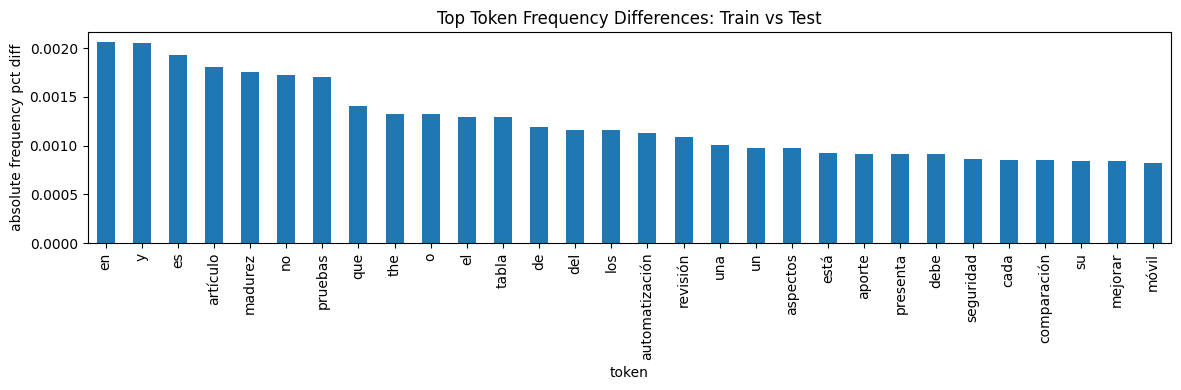

In [17]:
# ============================================================
# 9. Train/Test N-gram Drift
# ============================================================

def compare_token_distribution(counter_a, counter_b, top_n=100):
    total_a = sum(counter_a.values())
    total_b = sum(counter_b.values())
    vocab = set([tok for tok, _ in counter_a.most_common(top_n)]) | set([tok for tok, _ in counter_b.most_common(top_n)])
    rows = []
    for tok in vocab:
        pa = counter_a.get(tok, 0) / max(total_a, 1)
        pb = counter_b.get(tok, 0) / max(total_b, 1)
        rows.append({
            "token": tok,
            "train_pct": pa,
            "test_pct": pb,
            "abs_diff": abs(pa - pb),
            "ratio_test_train": (pb + 1e-12) / (pa + 1e-12),
        })
    return pd.DataFrame(rows).sort_values("abs_diff", ascending=False)

drift_tokens = compare_token_distribution(train_counter, test_counter, top_n=300)
display(drift_tokens.head(100))

plt.figure(figsize=(12, 4))
drift_tokens.head(30).set_index("token")["abs_diff"].plot(kind="bar")
plt.title("Top Token Frequency Differences: Train vs Test")
plt.ylabel("absolute frequency pct diff")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 9b. Adversarial Validation with TF-IDF
# ============================================================

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    max_rows = min(CONFIG["MAX_ROWS_FOR_HEAVY_EDA"], len(train_text), len(test_text))
    tr_sample = train_text.sample(max_rows, random_state=RANDOM_STATE)
    te_sample = test_text.sample(max_rows, random_state=RANDOM_STATE)

    adv_text = pd.concat([tr_sample, te_sample], axis=0).reset_index(drop=True)
    adv_y = np.array([0] * len(tr_sample) + [1] * len(te_sample))

    vec = TfidfVectorizer(
        lowercase=True,
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_features=100_000,
        sublinear_tf=True,
    )
    X_adv = vec.fit_transform(adv_text)

    idx = np.arange(len(adv_y))
    tr_idx, va_idx = train_test_split(idx, test_size=0.3, random_state=RANDOM_STATE, stratify=adv_y)

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_adv[tr_idx], adv_y[tr_idx])
    pred = clf.predict_proba(X_adv[va_idx])[:, 1]
    auc = roc_auc_score(adv_y[va_idx], pred)

    print(f"Text adversarial validation AUC: {auc:.5f}")
    print("~0.5 means train/test similar. High AUC means domain shift.")

except Exception as e:
    print("Adversarial text validation failed:", repr(e))

Text adversarial validation AUC: 0.43833
~0.5 means train/test similar. High AUC means domain shift.


## 10. Label Leakage and Suspicious Tokens

Use case:
- Some labels appear literally in text.
- IDs, filenames, URLs, or metadata may encode target.
- Need detect before trusting CV.

In [19]:
# ============================================================
# 10. Label Leakage and Suspicious Tokens
# ============================================================

if task_type in ["binary", "multiclass"]:
    labels = train[target_col].astype(str).unique().tolist()
    rows = []
    lower_text = train_text.str.lower()

    for lab in labels:
        lab_lower = str(lab).lower()
        if len(lab_lower) < 2:
            continue
        contains = lower_text.str.contains(re.escape(lab_lower), regex=True)
        rows.append({
            "label": lab,
            "label_appears_in_text_count": int(contains.sum()),
            "label_appears_in_text_pct": float(contains.mean()),
        })

    leakage_label_report = pd.DataFrame(rows).sort_values("label_appears_in_text_pct", ascending=False)
    display(leakage_label_report.head(50))
else:
    print("Label literal leakage check skipped for regression.")

# Check if text equals or contains ID.
if id_col is not None and id_col in train.columns:
    id_contains = []
    for i in range(min(len(train), CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])):
        val = str(train.iloc[i][id_col])
        txt = str(train_text.iloc[i])
        if len(val) >= 3 and val in txt:
            id_contains.append(i)
    print("Rows where ID appears in text sample:", len(id_contains))
    if len(id_contains) > 0:
        display(train.iloc[id_contains[:20]][[id_col, target_col, "_eda_text"]])

,label,label_appears_in_text_count,label_appears_in_text_pct
0,-1,4,0.012346
1,-2,3,0.009259


Rows where ID appears in text sample: 0


## 11. Text Cleaning Experiments

Use case:
- Decide whether cleaning helps.
- For TF-IDF, light cleaning often enough.
- For RNN/CNN from-scratch, normalize tokens to reduce vocabulary.

In [20]:
# ============================================================
# 11. Cleaning Functions and Vocabulary Impact
# ============================================================

def clean_variant_basic(x):
    x = normalize_space(x)
    return x

def clean_variant_lower_url_num(x):
    x = normalize_space(x).lower()
    x = re.sub(r"https?://\S+|www\.\S+", " <URL> ", x)
    x = re.sub(r"[\w\.-]+@[\w\.-]+", " <EMAIL> ", x)
    x = re.sub(r"@\w+", " <MENTION> ", x)
    x = re.sub(r"#(\w+)", r" <HASHTAG> \1 ", x)
    x = re.sub(r"\d+", " <NUM> ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def clean_variant_aggressive(x):
    x = clean_variant_lower_url_num(x)
    x = re.sub(r"[^\w\s<>]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

variants = {
    "basic": train_text.map(clean_variant_basic),
    "lower_url_num": train_text.map(clean_variant_lower_url_num),
    "aggressive": train_text.map(clean_variant_aggressive),
}

variant_rows = []
for name, ser in variants.items():
    cnt = build_counter(ser, max_rows=CONFIG["MAX_ROWS_FOR_HEAVY_EDA"])
    total_tokens = sum(cnt.values())
    variant_rows.append({
        "variant": name,
        "vocab_size": len(cnt),
        "total_tokens": total_tokens,
        "tokens_freq_ge_2": sum(1 for _, v in cnt.items() if v >= 2),
        "tokens_freq_ge_5": sum(1 for _, v in cnt.items() if v >= 5),
        "avg_word_count": ser.map(count_words).mean(),
    })

cleaning_report = pd.DataFrame(variant_rows)
display(cleaning_report)

,variant,vocab_size,total_tokens,tokens_freq_ge_2,tokens_freq_ge_5,avg_word_count
0,basic,6123,55020,3084,1298,168.777778
1,lower_url_num,5960,55594,3018,1272,179.126543
2,aggressive,5960,55594,3018,1272,171.774691


## 12. Recommendations for No-Pretrained NLP Modeling

Use case:
- Translate EDA findings into robust baseline choices.
- Since pretrained forbidden, primary options are:
  1. TF-IDF + linear model
  2. word-level CNN/RNN from scratch
  3. char-level CNN if OOV/noisy

In [21]:
# ============================================================
# 12. Automatic Recommendations
# ============================================================

recommendations = []

# Length-based
word_p95 = train_stats["word_count"].quantile(0.95)
word_p99 = train_stats["word_count"].quantile(0.99)
recommendations.append(f"For RNN/CNN max_len: start around p95={word_p95:.0f} words; if enough compute use p99={word_p99:.0f}.")

# Vocab based
for min_freq in [2, 3, 5]:
    vocab_size = sum(1 for _, cnt in train_counter.items() if cnt >= min_freq)
    recommendations.append(f"With min_freq={min_freq}, word vocab size ~{vocab_size}. Add PAD/UNK tokens.")

oov_rate = test_oov_tokens / max(test_total_tokens, 1)
if oov_rate > 0.10:
    recommendations.append(f"High test OOV token rate ({oov_rate:.2%}). Consider char n-gram TF-IDF or char CNN.")
else:
    recommendations.append(f"Test OOV token rate ({oov_rate:.2%}) is manageable for word-level model.")

# Noise
if "train_noise" in globals():
    if train_noise["has_url"].mean() > 0.02:
        recommendations.append("Normalize URLs to <URL>.")
    if train_noise["has_mention"].mean() > 0.02:
        recommendations.append("Normalize mentions to <MENTION>.")
    if train_noise["has_digit"].mean() > 0.10:
        recommendations.append("Consider normalizing numbers to <NUM>, but check if exact numbers matter.")

# Duplicate/conflict
if "conflicting" in globals() and len(conflicting) > 0:
    recommendations.append("Duplicate texts with conflicting labels exist. Use robust validation and inspect noisy labels.")

# Class imbalance
if task_type in ["binary", "multiclass"]:
    vc = train[target_col].value_counts()
    if vc.max() / max(vc.min(), 1) > 3:
        recommendations.append("Class imbalance detected. Use StratifiedKFold, class weights, macro F1, and threshold tuning.")

# Model recommendation
recommendations.append("Fast baseline: TF-IDF word(1,2) + char_wb(3,5) + LogisticRegression/LinearSVC.")
recommendations.append("No-pretrained neural baseline: Embedding from scratch + BiLSTM/GRU or TextCNN.")
recommendations.append("If text is very short/noisy: char-level TF-IDF or char CNN may beat word RNN.")

print("Recommendations:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

summary = {
    "target_col": target_col,
    "id_col": id_col,
    "text_cols": text_cols,
    "task_type": task_type,
    "n_train": len(train),
    "n_test": len(test),
    "train_vocab_size": len(train_counter),
    "test_vocab_size": len(test_counter),
    "test_oov_rate": oov_rate,
    "word_count_p95": float(word_p95),
    "word_count_p99": float(word_p99),
    "recommendations": recommendations,
}

with open("nlp_eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("\nSaved: nlp_eda_summary.json")

Recommendations:
1. For RNN/CNN max_len: start around p95=419 words; if enough compute use p99=690.
2. With min_freq=2, word vocab size ~3084. Add PAD/UNK tokens.
3. With min_freq=3, word vocab size ~2082. Add PAD/UNK tokens.
4. With min_freq=5, word vocab size ~1298. Add PAD/UNK tokens.
5. Test OOV token rate (6.12%) is manageable for word-level model.
6. Normalize URLs to <URL>.
7. Consider normalizing numbers to <NUM>, but check if exact numbers matter.
8. Duplicate texts with conflicting labels exist. Use robust validation and inspect noisy labels.
9. Fast baseline: TF-IDF word(1,2) + char_wb(3,5) + LogisticRegression/LinearSVC.
10. No-pretrained neural baseline: Embedding from scratch + BiLSTM/GRU or TextCNN.
11. If text is very short/noisy: char-level TF-IDF or char CNN may beat word RNN.

Saved: nlp_eda_summary.json


## 13. Manual Inspection Cells

Use case:
- Human inspection catches artifacts automated EDA misses.
- Look at shortest, longest, noisy, and random examples.

In [22]:
# ============================================================
# 13. Manual Inspection
# ============================================================

inspect_df = train[[target_col, "_eda_text"]].copy()
inspect_df["char_len"] = train_stats["char_len"]
inspect_df["word_count"] = train_stats["word_count"]
inspect_df["has_url"] = train_noise["has_url"]
inspect_df["has_non_ascii"] = train_noise["has_non_ascii"]

print("Shortest texts")
display(inspect_df.sort_values("char_len").head(20))

print("Longest texts")
display(inspect_df.sort_values("char_len", ascending=False).head(20))

print("Random sample")
display(inspect_df.sample(min(CONFIG["MAX_TEXT_EXAMPLES"], len(inspect_df)), random_state=RANDOM_STATE))

print("Noisy examples")
display(inspect_df[(inspect_df["has_url"]) | (inspect_df["has_non_ascii"])].head(50))

Shortest texts


,evaluation,_eda_text,char_len,word_count,has_url,has_non_ascii
321,0,[SEP1] [SEP2] 2010-07-05,26,3,False,False
150,2,[SEP1] [SEP2] 2010-07-05,26,3,False,False
11,0,[SEP1] [SEP2] 2010-07-05,26,3,False,False
190,2,[SEP1] [SEP2] 2010-07-05,26,3,False,False
158,2,[SEP1] [SEP2] 2010-07-05,26,3,False,False
316,1,[SEP1] [SEP2] 2010-07-05,26,3,False,False
129,2,Me ha gustado mucho Lo dejaría tal cual. [SEP1] [SEP2] 2010-07-05,66,11,False,True
18,2,"Un trabajo muy claro, preciso y del alto nivel [SEP1] [SEP2] 2010-07-05",72,12,False,False
44,-2,- No existen bases científicas explicitas en este trabajo y su aporte a la práctica es nulo. [SEP1] [SEP2] 2013-07-05,118,20,False,True
106,0,NO ME ENCUENTRO CAPACITADO PARA EFECTUAR ESTA REVISION. ESTA MUY LEJOS DE MI ESPECIALIZACION. [SEP1] [SEP2] 2010-07-05,119,17,False,False


Longest texts


,evaluation,_eda_text,char_len,word_count,has_url,has_non_ascii
76,-1,"• Revisar los conceptos de metodologías, métodos y modelos ya que son utilizados de manera indistinta, recomiendo revisar los términos, elegir el más apropiado y estandarizar su uso • Agregar referencia a afirmaciones que haces dentro de las diferentes secciones por ejemplo: ”la calidad de un si...",4852,771,False,True
66,-2,El artículo presenta una aplicación en el ámbito empresarial orientada al comercio minorista en la empresa comercial “Caracol” en Cuba. La temática del trabajo está orientada fundamentalmente a presentar y comentar la aplicación InfoCom y el cómo eventualmente funciona en la empresa. Sin embargo...,4643,748,False,True
308,-2,"El trabajo es de baja calidad académica (describe sólo una idea de proyecto y no da evidencias útiles para ser reportadas en ambientes académicos) y de muy pobre redacción (no depurado y sin claridad). No creo que sea un aporte al congreso. Ejemplos de carencias: 1. No existe ABSTRACT en inglés,...",4547,734,True,True
276,1,"La publicación tiene como objetivo mostrar las bondades que tienen las estructuras métricas para la recuperación de imágenes. Este trabajo es la continuación de varios trabajos ya presentados, como por ejemplo. [1] ""Estructuras métricas paralelas en la recuperación de imágenes"", Peña- Jaramillo,...",4376,699,True,True
137,0,"En cuanto a los aspectos generales, tres cosas: 1) los autores deberían de ser consistentes con la nomenclatura utilizada: principalmente requerimientos vs requisitos: por favor, utilicen solo una de las dos denominaciones, pero no mezclen a su antojo. 2) En segundo lugar, small settings (pequeñ...",3953,658,False,True
89,-2,"El artículo se titula ""Arquitectura de Software para la Automatización de Reglas de Negocio en la Recepción de Solicitudes de Crédito en Entidades Financieras"". En el resumen se indica que el trabajo tiene como objetivo proponer un modelo de automatización de reglas de negocio que logre desacopl...",3757,626,False,True
282,0,"El artículo trata la construcción de sistemas de recuperación de imágenes basada en el contenido (de las imágenes), CBIR. Se introduce el problema del CBIR y se presentan algunos algoritmos que permiten acelerar las búsquedas de vecinos más cercanos a un vector de entrada (correspondiente a una ...",3567,578,False,True
88,-1,RESUMEN. Este trabajo describe tres de actividades docentes en un curso electivo de la Universidad de La Serena. Desarrollar intérpretes usando la herramienta ANTLR en Android es la principal conexión de estas actividades. La primera actividad implementa un parser/interprete para una calculadora...,3505,529,True,True
153,-1,"El articulo narra la experiencia del desarrollo de una solución robotizada para el problema industrial de reparación de motores eléctricos. En particular, el problema de realizar soldaduras de precisión de motores eléctricos mediante un brazo robótico. El artículo presenta aspectos prácticos del...",3482,559,False,True
10,-2,"El tema es de actualidad y se recrea la tercera misión a través de la propuesta. Me parece meritoria e interesante, además del efecto multiplicador que esto conlleva para las empresas y las universidades en abordar problemas reales, con ""personas"" reales. Los Acrónimos definidos no presentan o r...",3471,536,True,True


Random sample


,evaluation,_eda_text,char_len,word_count,has_url,has_non_ascii
132,-2,"Este paper presenta problemas importantes en su formulación. Los papers de experiencias prácticas deben entregar algo más que una simple descripción del sistema desarrollado: deben indicar claramente qué nuevo conocimiento, técnica o solución se obtuvo de dicha experiencia. Consecuentemente, un ...",3201,480,False,True
108,2,Este trabajo propone un nuevo enfoque basado en [25] para apoyar la recomendación de los RS mediante la evolución de los pesos de las características de los usuarios a través de dos enfoques de utilización de algoritmos genéticos. El trabajo parece técnicamente correcto y la propuesta presenta r...,816,127,False,True
137,0,"En cuanto a los aspectos generales, tres cosas: 1) los autores deberían de ser consistentes con la nomenclatura utilizada: principalmente requerimientos vs requisitos: por favor, utilicen solo una de las dos denominaciones, pero no mezclen a su antojo. 2) En segundo lugar, small settings (pequeñ...",3953,658,False,True
9,2,"Resulta interesante el desarrollo de un web framework para la gestión de cámaras IP. Un tema que es, para mí, novedoso y que puede ser extendido en su utilidad. Hay problemas de redacción y presentación (por ejemplo, ""cuenta con una cámara IP las cuales pueden ...""). Además, queda poco claro si ...",631,100,False,True
180,2,"Artículo enfocado en las técnicas de educción de requisitos. Como comentario general, en las frases del tipo sujeto+verbo, no es necesario poner una coma después del sujeto (por ej., en la sección de introducción ""la educación de requisitos de software, es aquella ..."", en la de background ""la i...",1017,171,False,True
126,-2,"En este trabajo se muestra un Entorno visual interactivo para análisis exploratorio de modelos en minería de datos. Existe un trabajo denominado 'Modelo aumentado de árbol de decisión utilizando mapas autoorganizados', aceptado el año 2014 en revista Ingeniare, que muestra una metodología muy pa...",860,137,False,True
219,-2,"El artículo es un mero anuncio del trabajo de investigación que será realizado en una etapa posterior. Escasamente muestra el resumen del marco teórico, con sólo algunas referencias y un insuficiente estudio del estado del arte sobre el tema en cuestión. Por consiguiente no hay resultados en bas...",617,96,False,True
196,-1,El trabajo muestra el trabajo desarrollado para la construcción de una aplicación Web orientada a una interfaz móvil (tablet). La descripción del trabajo desarrollado no es detallada y deja muchas dudas sobre su implementación. Problemas de fondo encontrados: - Se describe la metodología RUP y B...,1569,258,False,True
266,2,El artículo describe un caso de innovación empresarial que apoya los procesos de aprendizaje organizacional. El principal mérito del caso es que se ha logrado un impacto muy significativo con una inversión modesta de recursos. Adicionalmente se enfatiza al conocimiento como un elemento estratégi...,490,72,False,True
144,2,"El trabajo presentado a Infonor - Chile, cumple con las expectativas siguientes: 1. Realiza una acertada discusión bibliográfica 2. Incorpora un algoritmo híbrido de búsqueda novedosa 3. Los resultados obtenidos con scheduling con restricciones usando el algoritmo (recursos limitados) muestra re...",423,57,False,True


Noisy examples


,evaluation,_eda_text,char_len,word_count,has_url,has_non_ascii
0,1,"Me parece un artículo interesante que pudo centrarse más en el desarrollo de una aplicación sobre Kurogo (un producto atractivo descrito en el artículo) que en el estudio de la ubicuidad de tecnologías para su interoperabilidad. En este punto me saltan diversas dudas, ya que el estudio concluye ...",1084,178,False,True
1,1,"Muy buen artículo para comprender la ubicación espacial de objetos, con propósitos de control, en este caso aplicable a un conjunto de robot en un juego de futbol. [SEP1] El paper es muy bueno, pero no es original, ya que tiene un alto índice de similitud con otros, no pudiendo identificar si se...",421,72,False,True
2,1,"Correcciones de Formato: 1. En palabras claves dejar sólo 5 las más relevantes. 2. Eliminar las siguientes expresiones: • “De ahí que en el sistema solar desentone la chatarra de los satélites artificiales, o en el sistema circulatorio sanguíneo produzca hemorragia la incrustación de una cuchill...",2339,393,True,True
3,2,"El artículo es interesante, abarca en profundidad muchos términos. Algunas observaciones son: - Deben ser entre 5 y 10 palabras clave. - Cambiar palabra ""entonro"" - Quitar acento a ""éste modo"" - No usar color según instrucciones de papers Infonor - Cambiar palabra ""Dendrograma"" - Revisar ""realiz...",334,52,False,True
4,1,"Los autores proponen el análisis de los datos a través de la metodología CRISP-DM, pero en el desarrollo no se utiliza el mismo. Los autores hacen uso de la herramienta WEKA y de los algoritmo que tiene implementados dicha herramienta. Tal vez fuera mejor pensar en un algoritmo propio para este ...",459,79,False,True
5,1,"Este es un tema que no ha sido abordado suficientemente y que por lo mismo es bueno el tratarlo en forma ""seria"". Justamente por lo planteado anteriormente, es que a esta temática se le puede ""sacar mayor partido"". A pesar que considero adecuada la clasificación deducida, creo que podría haberse...",348,57,False,True
6,2,"Muchos son los estudios sobre el efecto de las redes sociales, las oportunidades que pueden generar y de influencia en el comportamiento del consumidor. Quizás la más grande contribución de las redes sociales sean recriar la realidad en un Universo que puede ser mejor observable. Sin embargo muc...",1114,174,False,True
7,1,"Este paper, según los revisores, no contempla directamente una contribución científica, sin embargo la experiencia y el tema tratado son interesantes de presentar en el congreso. A pesar de que no puede ser presentado como paper regular en el congreso, ser recomienda aceptar el artículo para su ...",399,61,False,True
8,-1,"El trabajo pretende ofrecer una visión del uso de herramientas EVA en los diferentes entornos de asignaturas de enseñanza superior (presenciales, no presenciales y semipresenciales). La idea del paper es clara pero me cuesta trabajo encontrar la justificación de investigación del mismo. Los resu...",709,113,False,True
9,2,"Resulta interesante el desarrollo de un web framework para la gestión de cámaras IP. Un tema que es, para mí, novedoso y que puede ser extendido en su utilidad. Hay problemas de redacción y presentación (por ejemplo, ""cuenta con una cámara IP las cuales pueden ...""). Además, queda poco claro si ...",631,100,False,True
